In [1]:
import pandas as pd

df = pd.read_csv("HAM10000_metadata (1).csv")

In [2]:
metadata_df = pd.read_csv("/content/HAM10000_metadata (1).csv")

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB
None


In [4]:
print(df.isnull().sum())

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64


In [5]:
import zipfile
import os

os.makedirs("data/part1", exist_ok=True)
os.makedirs("data/part2", exist_ok=True)

with zipfile.ZipFile("HAM10000_images_part_1.zip", 'r') as zip_ref:
    zip_ref.extractall("data/part1")

with zipfile.ZipFile("HAM10000_images_part_2.zip", 'r') as zip_ref:
    zip_ref.extractall("data/part2")

In [6]:
import os

print(os.listdir("data/part1"))
print(os.listdir("data/part2"))

['ISIC_0026145.jpg', 'ISIC_0025447.jpg', 'ISIC_0029127.jpg', 'ISIC_0027962.jpg', 'ISIC_0025932.jpg', 'ISIC_0028488.jpg', 'ISIC_0025935.jpg', 'ISIC_0026556.jpg', 'ISIC_0026520.jpg', 'ISIC_0026733.jpg', 'ISIC_0029100.jpg', 'ISIC_0029022.jpg', 'ISIC_0027694.jpg', 'ISIC_0024623.jpg', 'ISIC_0024880.jpg', 'ISIC_0024309.jpg', 'ISIC_0028588.jpg', 'ISIC_0025575.jpg', 'ISIC_0028908.jpg', 'ISIC_0028040.jpg', 'ISIC_0025641.jpg', 'ISIC_0025496.jpg', 'ISIC_0026595.jpg', 'ISIC_0026081.jpg', 'ISIC_0024876.jpg', 'ISIC_0027300.jpg', 'ISIC_0025121.jpg', 'ISIC_0028472.jpg', 'ISIC_0024988.jpg', 'ISIC_0025644.jpg', 'ISIC_0024770.jpg', 'ISIC_0026158.jpg', 'ISIC_0025460.jpg', 'ISIC_0029215.jpg', 'ISIC_0029099.jpg', 'ISIC_0028246.jpg', 'ISIC_0025857.jpg', 'ISIC_0025750.jpg', 'ISIC_0026954.jpg', 'ISIC_0024579.jpg', 'ISIC_0028105.jpg', 'ISIC_0029103.jpg', 'ISIC_0026199.jpg', 'ISIC_0025617.jpg', 'ISIC_0026189.jpg', 'ISIC_0027426.jpg', 'ISIC_0029137.jpg', 'ISIC_0026767.jpg', 'ISIC_0024723.jpg', 'ISIC_0027333.jpg',

In [7]:
import pandas as pd

df = pd.read_csv("HAM10000_metadata (1).csv")

In [8]:
import os

image_path = {}

for folder in ["data/part1", "data/part2"]:
    for img in os.listdir(folder):
        image_id = img.split('.')[0]
        image_path[image_id] = os.path.join(folder, img)

In [9]:
df['path'] = df['image_id'].map(image_path.get)

In [10]:
df['path'].isnull().sum()

np.int64(0)

In [11]:
df = df.dropna(subset=['path'])
df = df.reset_index(drop=True)

In [12]:
df = df.dropna(subset=['age'])
df = df.reset_index(drop=True)

In [13]:
print("Missing age:", df['age'].isnull().sum())
print("Missing path:", df['path'].isnull().sum())

Missing age: 0
Missing path: 0


In [14]:
pip install scikit-image opencv-python pandas numpy

In [15]:
import os
import cv2

# Input folders
folder1 = "data/part1"
folder2 = "data/part2"

# Output folder
output_folder = "data/resized"

# Create output folder if not exists
os.makedirs(output_folder, exist_ok=True)


def process_and_resize(input_folder):
    for file in os.listdir(input_folder):
        if file.endswith(".jpg"):
            input_path = os.path.join(input_folder, file)

            img = cv2.imread(input_path)

            if img is None:
                continue

            # 🔥 Resize to 128x128
            img_resized = cv2.resize(img, (128, 128))

            # Save with same name
            output_path = os.path.join(output_folder, file)
            cv2.imwrite(output_path, img_resized)


# Process both folders
process_and_resize(folder1)
process_and_resize(folder2)

print("✅ All images resized and saved to data/resized/")

✅ All images resized and saved to data/resized/


In [16]:
import os
import cv2
import numpy as np
import pandas as pd
from skimage.feature import graycomatrix, graycoprops

# Folder containing resized images
image_folder = "data/resized"


def extract_glcm_features(img):
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Reduce intensity levels (0–255 → 0–15)
    gray = (gray / 16).astype(np.uint8)

    # Create GLCM matrix
    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0],
        levels=16,
        symmetric=True,
        normed=True
    )

    # Extract features
    contrast = graycoprops(glcm, 'contrast')[0, 0]
    correlation = graycoprops(glcm, 'correlation')[0, 0]
    energy = graycoprops(glcm, 'energy')[0, 0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0, 0]

    return [contrast, correlation, energy, homogeneity]


# Store results
features = []
image_ids = []

for file in os.listdir(image_folder):
    if file.endswith(".jpg"):
        path = os.path.join(image_folder, file)

        img = cv2.imread(path)

        if img is None:
            continue

        feat = extract_glcm_features(img)

        features.append(feat)
        image_ids.append(file.replace(".jpg", ""))


# Create DataFrame
glcm_df = pd.DataFrame(features, columns=[
    "contrast",
    "correlation",
    "energy",
    "homogeneity"
])

glcm_df["image_id"] = image_ids

print(glcm_df.head())

# Save to CSV
glcm_df.to_csv("glcm_features.csv", index=False)

print("✅ GLCM features extracted and saved!")

   contrast  correlation    energy  homogeneity      image_id
0  0.253260     0.979134  0.373294     0.879571  ISIC_0026145
1  0.206754     0.972983  0.460557     0.899280  ISIC_0025447
2  0.439838     0.979275  0.265557     0.806885  ISIC_0034136
3  0.494894     0.891708  0.310948     0.820594  ISIC_0029929
4  0.198388     0.974899  0.387932     0.902504  ISIC_0032062
✅ GLCM features extracted and saved!


In [17]:
print(len(glcm_df))

10015


In [18]:
print(glcm_df.isnull().sum())

contrast       0
correlation    0
energy         0
homogeneity    0
image_id       0
dtype: int64


In [19]:
import cv2
import numpy as np

def extract_hsv_features(img):
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    h_hist = cv2.calcHist([hsv], [0], None, [16], [0, 180])
    s_hist = cv2.calcHist([hsv], [1], None, [16], [0, 256])
    v_hist = cv2.calcHist([hsv], [2], None, [16], [0, 256])

    h_hist = cv2.normalize(h_hist, h_hist).flatten()
    s_hist = cv2.normalize(s_hist, s_hist).flatten()
    v_hist = cv2.normalize(v_hist, v_hist).flatten()

    return np.concatenate([h_hist, s_hist, v_hist])

In [ ]:
# ── HSV features: load from Member 1's CSV output ──────────────────────────
# Member 1 extracts and saves hsv_features.csv (48 cols + image_id).
# We load it here and use it directly in the merge step.

import pandas as pd
import os

HSV_CSV = "hsv_features.csv"

if os.path.exists(HSV_CSV):
    hsv_df = pd.read_csv(HSV_CSV)
    print(f"Loaded {HSV_CSV}  shape: {hsv_df.shape}")
else:
    # Fallback: extract HSV here if M1's CSV is not yet available
    print(f"{HSV_CSV} not found — extracting HSV features locally as fallback...")
    image_folder = "data/resized"
    hsv_rows, image_ids = [], []

    for file in os.listdir(image_folder):
        if file.endswith(".jpg"):
            path = os.path.join(image_folder, file)
            img = cv2.imread(path)
            if img is None:
                continue
            hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            h_hist = cv2.normalize(cv2.calcHist([hsv],[0],None,[16],[0,180]),None).flatten()
            s_hist = cv2.normalize(cv2.calcHist([hsv],[1],None,[16],[0,256]),None).flatten()
            v_hist = cv2.normalize(cv2.calcHist([hsv],[2],None,[16],[0,256]),None).flatten()
            feat = list(h_hist) + list(s_hist) + list(v_hist)
            hsv_rows.append(feat)
            image_ids.append(file.replace(".jpg", ""))

    col_names = [f"h_{i}" for i in range(16)] + [f"s_{i}" for i in range(16)] + [f"v_{i}" for i in range(16)]
    hsv_df = pd.DataFrame(hsv_rows, columns=col_names)
    hsv_df["image_id"] = image_ids
    hsv_df.to_csv(HSV_CSV, index=False)
    print(f"Extracted and saved {HSV_CSV}  shape: {hsv_df.shape}")

print("Sample:")
print(hsv_df.head(2))


ABCD FEATURES


In [21]:
import cv2
import numpy as np

def segment_lesion(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Smooth noise
    blur = cv2.GaussianBlur(gray, (5, 5), 0)

    # Otsu threshold
    _, thresh = cv2.threshold(
        blur, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # Ensure lesion is white
    if np.mean(thresh) > 127:
        thresh = cv2.bitwise_not(thresh)

    return thresh

In [22]:
def compute_asymmetry(mask):
    h, w = mask.shape

    left = mask[:, :w//2]
    right = mask[:, w//2:]

    # Flip right side
    right_flipped = cv2.flip(right, 1)

    # Resize if mismatch
    right_flipped = cv2.resize(right_flipped, (left.shape[1], left.shape[0]))

    diff = cv2.absdiff(left, right_flipped)

    asymmetry = np.sum(diff) / (h * w)

    return asymmetry

In [23]:
def compute_border_irregularity(mask):
    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return 0

    cnt = max(contours, key=cv2.contourArea)

    area = cv2.contourArea(cnt)
    perimeter = cv2.arcLength(cnt, True)

    if area == 0:
        return 0

    # Circularity measure
    irregularity = (perimeter ** 2) / (4 * np.pi * area)

    return irregularity

In [24]:
import os
import pandas as pd
import cv2
import numpy as np

image_folder = "data/resized"

shape_features = []
image_ids = []

for file in os.listdir(image_folder):
    if file.endswith(".jpg"):
        path = os.path.join(image_folder, file)

        img = cv2.imread(path)

        if img is None:
            continue

        mask = segment_lesion(img)

        # =========================
        # 🔧 STEP 1: CLEAN MASK
        # =========================
        kernel = np.ones((5, 5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

        # =========================
        # 🔧 STEP 2: FIND CONTOURS
        # =========================
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(contours) == 0:
            continue

        cnt = max(contours, key=cv2.contourArea)

        area = cv2.contourArea(cnt)

        # =========================
        # 🔧 STEP 3: FILTER NOISE
        # =========================
        if area < 50:
            continue

        # =========================
        # 🔧 STEP 4: SMOOTH CONTOUR
        # =========================
        epsilon = 0.01 * cv2.arcLength(cnt, True)
        cnt = cv2.approxPolyDP(cnt, epsilon, True)

        perimeter = cv2.arcLength(cnt, True)

        if perimeter == 0:
            continue

        # =========================
        # 🔧 STEP 5: FEATURES
        # =========================
        border = (perimeter ** 2) / (4 * np.pi * area)

        x, y, w, h = cv2.boundingRect(cnt)
        roi = mask[y:y+h, x:x+w]

        flipped = cv2.flip(roi, 1)
        diff = cv2.absdiff(roi, flipped)

        asym = np.sum(diff) / (np.sum(roi) + 1e-6)

        # =========================
        # 🔧 STEP 6: REMOVE BAD VALUES
        # =========================
        if border > 15:
            continue

        shape_features.append([asym, border])
        image_ids.append(file.replace(".jpg", ""))


shape_df = pd.DataFrame(shape_features, columns=[
    "asymmetry",
    "border_irregularity"
])

shape_df["image_id"] = image_ids

shape_df.to_csv("shape_features.csv", index=False)

print("✅ Shape features done ")

✅ Shape features done 


In [25]:
print(shape_df.isnull().sum())

asymmetry              0
border_irregularity    0
image_id               0
dtype: int64


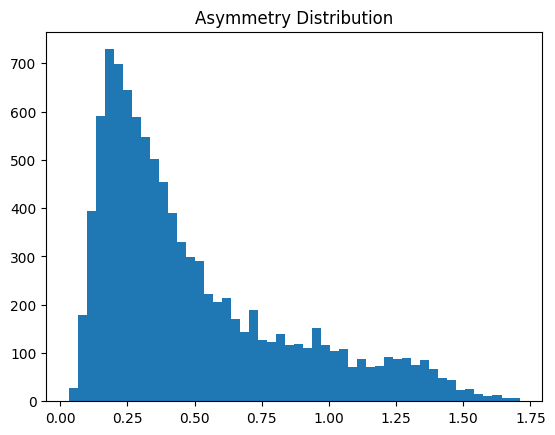

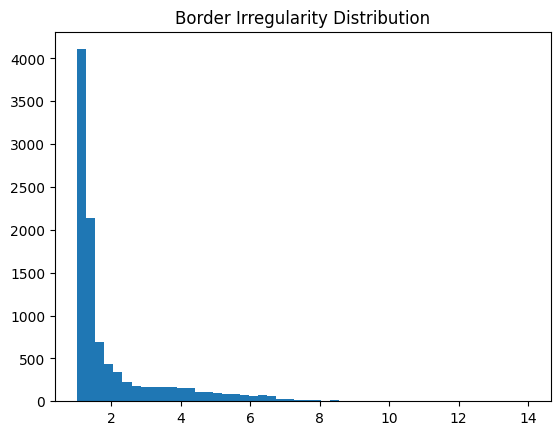

In [26]:
import matplotlib.pyplot as plt

plt.hist(shape_df["asymmetry"], bins=50)
plt.title("Asymmetry Distribution")
plt.show()

plt.hist(shape_df["border_irregularity"], bins=50)
plt.title("Border Irregularity Distribution")
plt.show()

In [27]:
print(shape_df.sort_values("asymmetry", ascending=False).head())
print(shape_df.sort_values("border_irregularity", ascending=False).head())

      asymmetry  border_irregularity      image_id
6963   1.709775             3.478543  ISIC_0031762
7270   1.708626             3.770224  ISIC_0026218
9347   1.703636             5.566069  ISIC_0027204
3537   1.689846             8.566892  ISIC_0030539
3824   1.687651             5.214017  ISIC_0029104
      asymmetry  border_irregularity      image_id
1318   0.523977            14.006096  ISIC_0026466
484    0.546512            12.714429  ISIC_0029919
4113   1.037212            11.787791  ISIC_0029041
6994   0.616232            11.630013  ISIC_0024926
3215   0.319300            10.710009  ISIC_0028735


In [ ]:
# ── Feature Merge: GLCM + HSV + Shape + Metadata ───────────────────────────
import pandas as pd
import os

# Load each feature CSV
glcm_df = pd.read_csv("glcm_features.csv")
hsv_df  = pd.read_csv("hsv_features.csv")
shape_df = pd.read_csv("shape_features.csv")

# Metadata: prefer Member 1's cleaned version, fallback to raw CSV
if os.path.exists("cleaned_metadata.csv"):
    metadata_df = pd.read_csv("cleaned_metadata.csv")
    print("Using cleaned_metadata.csv from Member 1 (age outliers removed)")
else:
    metadata_df = pd.read_csv("HAM10000_metadata (1).csv")
    print("Using raw metadata CSV (cleaned_metadata.csv not found)")

print(f"GLCM   : {glcm_df.shape}")
print(f"HSV    : {hsv_df.shape}")
print(f"Shape  : {shape_df.shape}")
print(f"Meta   : {metadata_df.shape}")

# Merge all on image_id
df = glcm_df.merge(hsv_df,     on="image_id", how="inner")
df = df.merge(shape_df,        on="image_id", how="inner")
df = df.merge(metadata_df,     on="image_id", how="inner")

print(f"\nMerged dataframe: {df.shape}")
print("Columns:", list(df.columns))


In [29]:
print(df.columns)

Index([           'contrast',         'correlation',              'energy',
               'homogeneity',            'image_id',                     0,
                           1,                     2,                     3,
                           4,                     5,                     6,
                           7,                     8,                     9,
                          10,                    11,                    12,
                          13,                    14,                    15,
                          16,                    17,                    18,
                          19,                    20,                    21,
                          22,                    23,                    24,
                          25,                    26,                    27,
                          28,                    29,                    30,
                          31,                    32,                    33,
            

DATASET CLEANING AND CHANGES

In [30]:
df = df.drop(columns=["image_id", "lesion_id", "dx_type"])

In [31]:
# Fix: use fillna(2) for unknown/other sex values to avoid NaN after mapping
df["sex"] = df["sex"].map({"male": 0, "female": 1}).fillna(2).astype(int)

In [32]:
df = pd.get_dummies(df, columns=["localization"])

In [33]:
print(df.isnull().sum())

contrast                        0
correlation                     0
energy                          0
homogeneity                     0
0                               0
                               ..
localization_neck               0
localization_scalp              0
localization_trunk              0
localization_unknown            0
localization_upper extremity    0
Length: 72, dtype: int64


In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label"] = le.fit_transform(df["dx"])

FEATURE SPLIT, TRAIN SPLIT AND SMOTE

In [35]:
# ── Fix NaNs before SMOTE ──────────────────────────────────────────
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

# Drop the "label" column from X (it is a duplicate of "dx" encoded)
# Keep only numeric/dummy columns as features
feature_cols = [c for c in df.columns if c not in ["dx", "label"]]
X = df[feature_cols].copy()
y = df["dx"]                        # string labels — LabelEncoder already in le

# Ensure all column names are strings (required by sklearn)
X.columns = X.columns.astype(str)

# Impute any remaining NaNs with column median
imputer = SimpleImputer(strategy="median")
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=X.columns)

print("NaNs in X after imputation:", X.isnull().sum().sum())   # must be 0
print("X shape:", X.shape)
print("y shape:", y.shape)

NaNs in X after imputation: 0
X shape: (10015, 71)
y shape: (10015,)


In [36]:
# ── Train / Test split ──────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (8012, 71)
Test size:  (2003, 71)


In [37]:
# ── SMOTE — oversample minority classes on TRAIN only ───────────────
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder

# SMOTE needs numeric labels
le2 = LabelEncoder()
y_train_enc = le2.fit_transform(y_train)
y_test_enc  = le2.transform(y_test)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train_enc)

print("Before SMOTE:", X_train.shape[0], "samples")
print("After  SMOTE:", X_train_sm.shape[0], "samples")

unique, counts = np.unique(y_train_sm, return_counts=True)
for cls, cnt in zip(le2.classes_, counts):
    print(f"  {cls}: {cnt}")

Before SMOTE: 8012 samples
After  SMOTE: 37548 samples
  akiec: 5364
  bcc: 5364
  bkl: 5364
  df: 5364
  mel: 5364
  nv: 5364
  vasc: 5364


In [38]:
# ── StandardScaler — fit on train, transform both ───────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)

## Model Training — SVM, Random Forest, XGBoost

In [39]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import joblib, os

os.makedirs("models", exist_ok=True)

# SVM — RBF kernel
print("Training SVM...")
svm = SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=42)
svm.fit(X_train_sc, y_train_sm)
joblib.dump(svm, "models/svm_model.pkl")
print("  SVM done")

# Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train_sm)
joblib.dump(rf, "models/rf_model.pkl")
print("  RF done")

# XGBoost
print("Training XGBoost...")
xgb_clf = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    eval_metric="mlogloss", random_state=42, n_jobs=-1
)
xgb_clf.fit(X_train_sc, y_train_sm)
joblib.dump(xgb_clf, "models/xgb_model.pkl")
print("  XGBoost done")

# Save scaler + encoder for Streamlit
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(le2,    "models/label_encoder.pkl")
print("All models saved to /models")

Training SVM...
  SVM done
Training Random Forest...
  RF done
Training XGBoost...
  XGBoost done
All models saved to /models


## Evaluation — Class-wise Sensitivity & Specificity

In [40]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

CLASS_NAMES = le2.classes_

def sensitivity_specificity(y_true, y_pred, class_names):
    """
    For each class compute:
      Sensitivity (Recall) = TP / (TP + FN)
      Specificity          = TN / (TN + FP)
    using a one-vs-rest confusion matrix.
    """
    rows = []
    cm = confusion_matrix(y_true, y_pred)
    for i, cls in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - TP - FN - FP
        sens = TP / (TP + FN + 1e-9)
        spec = TN / (TN + FP + 1e-9)
        rows.append({"Class": cls,
                     "Sensitivity": round(sens, 3),
                     "Specificity": round(spec, 3)})
    return pd.DataFrame(rows)

results = {}
for name, clf in [("SVM", svm), ("Random Forest", rf), ("XGBoost", xgb_clf)]:
    y_pred = clf.predict(X_test_sc)
    df_ss  = sensitivity_specificity(y_test_enc, y_pred, CLASS_NAMES)
    results[name] = {"y_pred": y_pred, "sens_spec": df_ss}
    print(f"\n===== {name} =====")
    print(df_ss.to_string(index=False))
    print("\nClassification Report:")
    print(classification_report(y_test_enc, y_pred, target_names=CLASS_NAMES))


===== SVM =====
Class  Sensitivity  Specificity
akiec        0.492        0.970
  bcc        0.437        0.976
  bkl        0.550        0.947
   df        0.391        0.995
  mel        0.466        0.938
   nv        0.900        0.769
 vasc        0.286        0.997

Classification Report:
              precision    recall  f1-score   support

       akiec       0.36      0.49      0.41        65
         bcc       0.50      0.44      0.47       103
         bkl       0.56      0.55      0.56       220
          df       0.50      0.39      0.44        23
         mel       0.48      0.47      0.47       223
          nv       0.89      0.90      0.89      1341
        vasc       0.57      0.29      0.38        28

    accuracy                           0.76      2003
   macro avg       0.55      0.50      0.52      2003
weighted avg       0.76      0.76      0.76      2003


===== Random Forest =====
Class  Sensitivity  Specificity
akiec        0.369        0.974
  bcc        0.

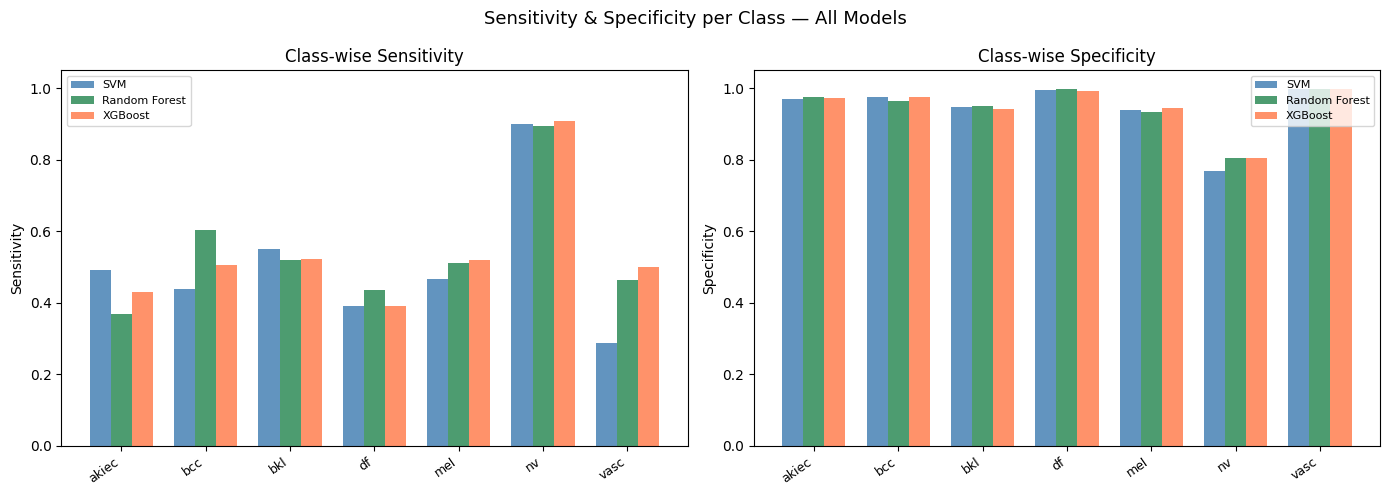

Plot saved.


In [41]:
# ── Plot class-wise Sensitivity & Specificity for all models ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(CLASS_NAMES))
width = 0.25
colors = ["steelblue", "seagreen", "coral"]

for ax, metric in zip(axes, ["Sensitivity", "Specificity"]):
    for i, (name, res) in enumerate(results.items()):
        vals = res["sens_spec"][metric].values
        ax.bar(x + i*width, vals, width, label=name, color=colors[i], alpha=0.85)
    ax.set_xticks(x + width)
    ax.set_xticklabels(CLASS_NAMES, rotation=35, ha="right", fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Class-wise {metric}", fontsize=12)
    ax.legend(fontsize=8)
    ax.set_ylabel(metric)

plt.suptitle("Sensitivity & Specificity per Class — All Models", fontsize=13)
plt.tight_layout()
plt.savefig("models/sensitivity_specificity.png", dpi=150)
plt.show()
print("Plot saved.")

## Feature Group Comparison — Clinically Relevant Discriminators

In [ ]:
# ── Feature Group Comparison: GLCM vs HSV vs Shape (SVM accuracy) ──────────

all_cols = list(X.columns)

# GLCM: 4 texture features
glcm_cols  = [c for c in all_cols if c in ["contrast","correlation","energy","homogeneity"]]

# HSV: named h_0..h_15, s_0..s_15, v_0..v_15 (48 cols from M1)
hsv_cols   = [c for c in all_cols if c.startswith(("h_","s_","v_")) and
              c.split("_")[1].isdigit() and int(c.split("_")[1]) < 16]

# Shape: ABCD asymmetry + border
shape_cols = [c for c in all_cols if c in ["asymmetry","border_irregularity"]]

print("GLCM cols :", glcm_cols)
print("HSV cols  :", len(hsv_cols), "columns")
print("Shape cols:", shape_cols)

group_scores = {}
for group_name, cols in [("GLCM (texture)",  glcm_cols),
                          ("HSV (colour)",    hsv_cols),
                          ("Shape (ABCD)",    shape_cols),
                          ("All combined",    all_cols)]:
    if len(cols) == 0:
        print(f"  Skipping {group_name} — no columns found")
        continue

    idx = [all_cols.index(c) for c in cols]
    X_tr_g = X_train_sc[:, idx]
    X_te_g = X_test_sc[:, idx]

    clf_g = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
    clf_g.fit(X_tr_g, y_train_sm)
    acc = clf_g.score(X_te_g, y_test_enc)
    group_scores[group_name] = round(acc, 3)
    print(f"  {group_name:20s}: accuracy = {acc:.3f}")


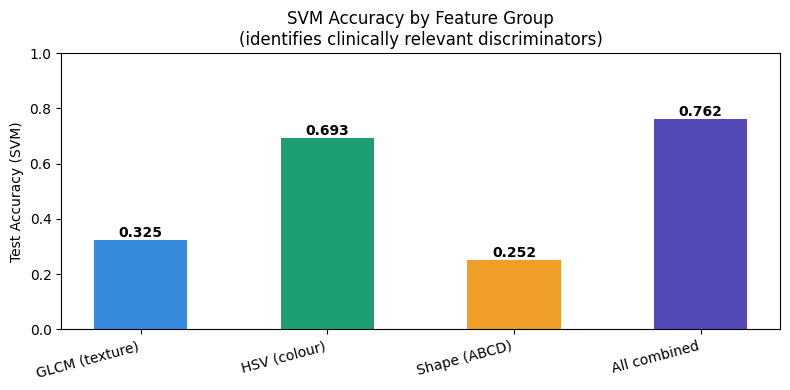


Conclusion: the group with the highest accuracy is the strongest
clinical discriminator for skin lesion classification.


In [43]:
# ── Bar chart: feature group accuracy ───────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = ["#378ADD", "#1D9E75", "#EF9F27", "#534AB7"]
groups = list(group_scores.keys())
accs   = list(group_scores.values())

bars = ax.bar(groups, accs, color=bar_colors[:len(groups)], width=0.5)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Test Accuracy (SVM)")
ax.set_title("SVM Accuracy by Feature Group\n(identifies clinically relevant discriminators)")
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("models/feature_group_comparison.png", dpi=150)
plt.show()
print("\nConclusion: the group with the highest accuracy is the strongest")
print("clinical discriminator for skin lesion classification.")

In [44]:
# ── Summary comparison table across all 3 models ────────────────────
from sklearn.metrics import classification_report

summary_rows = []
for name, res in results.items():
    rep = classification_report(y_test_enc, res["y_pred"],
                                target_names=CLASS_NAMES, output_dict=True)
    summary_rows.append({
        "Model":       name,
        "Macro F1":    round(rep["macro avg"]["f1-score"], 3),
        "Macro Prec":  round(rep["macro avg"]["precision"], 3),
        "Macro Recall":round(rep["macro avg"]["recall"], 3),
        "Accuracy":    round(rep["accuracy"], 3)
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
summary_df.to_csv("models/model_comparison.csv", index=False)
print("\nSaved to models/model_comparison.csv")

        Model  Macro F1  Macro Prec  Macro Recall  Accuracy
          SVM     0.518       0.551         0.503     0.762
Random Forest     0.559       0.597         0.542     0.766
      XGBoost     0.554       0.580         0.540     0.775

Saved to models/model_comparison.csv
